# SABR Model

**What this is:** SABR (Hagan et al., 2002) models a forward price with stochastic
volatility, where $\beta$ sets the elasticity of the process, i.e. $\beta = 0$ gives a
normal (Bachelier style) model, $\beta = 1$ gives a lognormal (Black style) model, and
intermediate values interpolate between the two.

**Why it matters:** SABR became the market standard for interest rate derivatives, not
due to fitting better than Heston, but because Hagan's asymptotic expansion gives implied
volatility as an explicit formula, which makes fitting an entire smile fast enough to be
used in live trading. It is also worth noting that the process is driftless by
construction, since a forward is already a martingale under its own measure.

## Setup

**Reproducibility:** this notebook is seeded, so re-running it reproduces the figures
exactly. A seed fixes the sample rather than the conclusion, so any claim made here
should hold across seeds rather than only at this one. Note also that NumPy guarantees
the `default_rng` stream for a given version rather than indefinitely, which is part of
why `requirements.txt` is pinned.

In [1]:
from __future__ import annotations

import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt

Array = npt.NDArray[np.float64]
RNG = int | np.random.Generator | None

plt.style.use("seaborn-v0_8")

## Parameters

| Symbol | Code | Meaning |
|---|---|---|
| $F_0$ | `F0` | initial forward price |
| $\alpha_0$ | `alpha0` | initial instantaneous volatility of the forward |
| $\beta$ | `beta` | elasticity, $\beta = 0$ is normal (Bachelier style) and $\beta = 1$ is lognormal (Black style) |
| $\nu$ | `nu` | volatility of volatility, controlling the variance of the $\alpha$ process |
| $\rho$ | `rho` | correlation between the forward and volatility shocks |
| $T$ | `T` | time to maturity in years |
| $n$ | `n` | number of time steps (252 trading days) |
| $\Delta t$ | `dt` | time step size, $\Delta t = T/n$ |
| $W^{F}_{i,j},\ W^{\alpha}_{i,j}$ | `W_F`, `W_alpha` | correlated standard normal shocks driving the two processes |

In [2]:
SEED = 20260913

T = 1
n = 252
dt = T/n
rho = -0.7
num_paths = 100
nu = 0.04
F0 = 1
alpha0 = 0.2
beta = 1

## Model

**Continuous time:** the forward is driftless, since a forward price is already a
martingale under its own measure,

$$dF_t = \alpha_t F_t^{\beta} \, dW^{F}_t$$

$$d\alpha_t = \nu \alpha_t \, dW^{\alpha}_t,
\qquad d\langle W^{F}, W^{\alpha} \rangle_t = \rho \, dt$$

**Correlated shocks:**

$$W^{\alpha}_{i,j} = \rho \, W^{F}_{i,j} + \sqrt{1 - \rho^2} \, Z_{i,j},
\qquad W^{F}_{i,j}, Z_{i,j} \sim \mathcal{N}(0,1)$$

**Discrete time:** the volatility process is a driftless geometric Brownian motion, so it
is sampled exactly in logs. The forward has no closed form for general $\beta$ and is
stepped with Euler, then floored at zero to stop $F^{\beta}$ being evaluated at a negative
base.

$$\alpha_{i+1,j} = \alpha_{i,j}
\exp\!\left( -\tfrac{1}{2}\nu^2 \Delta t + \nu \sqrt{\Delta t} \, W^{\alpha}_{i,j} \right)$$

$$F_{i+1,j} = \max\!\left( F_{i,j}
+ \alpha_{i,j} F_{i,j}^{\beta} \sqrt{\Delta t} \, W^{F}_{i,j},\ 0 \right)$$

where $i$ indexes time and $j$ indexes paths, with $i \in [0, n-1]$ and $j \in [1, \texttt{num\_paths}]$.

**In code:** the loop steps `alpha` and `F` together, with the correlated shocks built as
`W_alpha = rho * Z_1 + np.sqrt(1 - rho**2) * Z_2`. The floor is `np.maximum(..., 0)`, and
both arrays are stored as `(n + 1, num_paths)`, matching the $(i, j)$ ordering above.

In [3]:
def simulate_sabr(F0: float, alpha0: float, beta: float, nu: float, rho: float,
                  n: int, dt: float, num_paths: int,
                  rng: RNG = None) -> tuple[Array, Array]:
  """SABR forward and volatility paths, each shape (n+1, num_paths).

  The volatility process is a driftless geometric Brownian motion and is sampled
  exactly in logs. The forward has no closed form for general beta, so it is
  stepped with Euler and floored at zero to stop F**beta being evaluated at a
  negative base.

  Returns (F, alpha), each shape (n+1, num_paths), time along the first axis.
  """
  rng = np.random.default_rng(rng)
  Z_1 = rng.normal(0,1,(n,num_paths))
  Z_2 = rng.normal(0,1,(n,num_paths))

  W_F = Z_1
  W_alpha = rho * Z_1 + np.sqrt(1-rho**2) * Z_2

  alpha = np.zeros((n+1,num_paths)); alpha[0,:] = alpha0
  F = np.zeros((n+1,num_paths)); F[0,:] = F0

  for i in range(0,n):
    alpha[i+1] = alpha[i] * np.exp(-0.5 * nu**2 * dt + nu * np.sqrt(dt) * W_alpha[i])
    F[i+1] = np.maximum(F[i] + alpha[i] * F[i] ** beta * np.sqrt(dt) * W_F[i],0)

  return F, alpha

F, alpha = simulate_sabr(F0, alpha0, beta, nu, rho, n, dt, num_paths, rng=SEED)

## Results

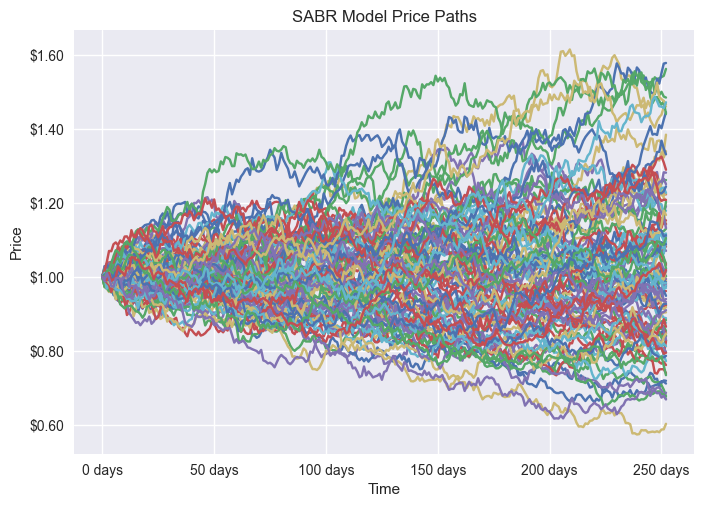

In [4]:
plt.plot(F)
plt.grid(True)
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("SABR Model Price Paths")
plt.gca().yaxis.set_major_formatter("${x:,.2f}")
plt.gca().xaxis.set_major_formatter("{x:,.0f} days")
plt.show()